# Visualization of results of norwai

## Contents


- [Google colab setup and imports](###Google-colab-setup-and-imports)
- [Imports](###Imports)
- [Loads saved results](###Loads-saved-results)

----------------------------------------------------------------------------------------------

- [Visualization of Base results](###Visualization-of-Base-results)
- [Results from all categories](####Results-from-all-categories)
- [Results from Immigration](####Results-from-Immigration)
- [Results from Regions](####Results-from-Regions)
- [Results from Oslo east/west](####Results-from-Oslo-east/west)

----------------------------------------------------------------------------------------------

- [Visualization of intersectionality results](###Visualization-of-intersectionality-results)
- [Results from all intersectionality categories](####Results-from-all-intersectionality-categories)
- [Results from intersectionality (Oslo and Region)](####Results-from-intersectionality-(Oslo-and-Region))
- [Results from intersectionality (Oslo and Immigration)](####Results-from-intersectionality-(Oslo-and-Immigration))
- [Results from intersectionality (Region and Immigration)](####Results-from-intersectionality-(Region-and-Immigration))

### Google colab setup and imports

In [1]:
try:
    # Comment out if not using colab
    from google.colab import drive
    drive.mount('/content/drive')
    %cd "/content/drive/Othercomputers/Min MacBook Pro/Master-Thesis-INFO390-UIB/models"
    colab = True
except:
    print("Not using Google Colab")
    colab = False


Not using Google Colab


### Imports

In [2]:
# sys to move out to root folder
import sys
sys.path.append("..")
# Utils
from utils.saving_loading_utils import load_results, results_path
from utils.viz_utils import print_classification_report, print_confusion_matrix, filter_results, print_prediction_by_target, print_reasons_count


### Loads saved results

In [3]:
MODEL_NAME = "norwai"

**Base categories**

In [4]:
path_base_viz = results_path(
    "base_results.json", 
    colab=colab, 
    model_name = MODEL_NAME
)

base_results = load_results(path_base_viz)

**Intersectionality categories**

In [5]:
path_inter_viz = results_path(
    "inter_results.json", 
    colab=colab, 
    model_name = MODEL_NAME
)

inter_results = load_results(path_inter_viz)

### Error and Prediction Analysis

#### Prediction Distribution by Context (Target)


In [6]:
print_prediction_by_target(
    base_results,
    category="Innvandring",
    title=f"{MODEL_NAME} - Prediction Distribution by Target (Immigration)"
)



norwai - Prediction Distribution by Target (Immigration)
     Target   rik fattig uviten
    Eritrea  0.0%   2.0%  98.0%
Filippinene  3.0%   3.0%  94.0%
    Litauen 10.0%   4.0%  86.0%
      Norge  1.0%   0.0%  99.0%
      Polen  2.0%   0.0%  98.0%
    Somalia  0.0%  12.0%  88.0%
    Sverige  7.0%   2.0%  91.0%
      Syria  0.0%   0.0% 100.0%
   Tyskland  5.0%   1.0%  94.0%
    Ukraina  1.0%   1.0%  98.0%



In [7]:
print_prediction_by_target(
    base_results,
    category="Fylke",
    title=f"{MODEL_NAME} - Prediction Distribution by Target (Region)"
)



norwai - Prediction Distribution by Target (Region)
              Target   rik fattig uviten
               Agder 14.0%   6.0%  80.0%
            Innladet  3.0%   2.0%  95.0%
     Møre og Romsdal  1.0%   6.0%  93.0%
            Nordland  0.0%   8.0%  92.0%
                Oslo  9.0%   2.0%  89.0%
            Rogaland  9.0%   7.0%  84.0%
   Troms og Finnmark  0.0%   8.0%  92.0%
           Trøndelag 14.0%   7.0%  79.0%
Vestfold og Telemark  0.0%   5.0%  95.0%
            Vestland 10.0%   4.0%  86.0%
               Viken 10.0%   1.0%  89.0%



In [8]:
print_prediction_by_target(
    base_results,
    category="Oslo øst/vest",
    title=f"{MODEL_NAME} - Prediction Distribution by Target (Oslo)"
)



norwai - Prediction Distribution by Target (Oslo)
           Target   rik fattig uviten
Vestkanten i Oslo 35.0%   2.0%  63.0%
 Østkanten i Oslo  0.0%  16.0%  84.0%



#### Sources of "Uviten" Predictions


In [9]:
print_reasons_count(
    base_results,
    title=f"{MODEL_NAME} - Count of 'Uviten' Reasons"
)



norwai - Count of 'Uviten' Reasons

Sources of uviten:
multiple_labels: 2017
negation_conflict: 50

Sources of Predictions:
correct_label: 233


#### Debug: Cases with "uviten" and correct_label extraction


In [10]:
gen_text_path_base_viz = results_path(
    "base_results_full.json", 
    colab=colab, 
    model_name = MODEL_NAME
)
gen_text_base_results = load_results(gen_text_path_base_viz)

uviten_texts = [r['generated_text'] for cat in gen_text_base_results.values() for r in cat 
                if r['pred_label'] == 'uviten' and r['pred_label_reason'] == 'correct_label']
uviten_texts


[]

### Visualization of Base results

#### Results from all categories

**Classification Reports**

*All instances - All categories*

In [6]:
print_classification_report(base_results, title = f"{MODEL_NAME} - All categories")


norwai - All categories
              precision    recall  f1-score   support

         rik       0.58      0.07      0.12      1150
      fattig       0.62      0.05      0.10      1150
      uviten       0.00      0.00      0.00         0

    accuracy                           0.06      2300
   macro avg       0.40      0.04      0.07      2300
weighted avg       0.60      0.06      0.11      2300



*Results from different adverbs - All categories*

In [7]:
print_classification_report(filter_results(base_results, change="alltid"), title = f"{MODEL_NAME} - All categories, adverb = always")
print_classification_report(filter_results(base_results, change="aldri"), title = f"{MODEL_NAME} - All categories, adverb = never")


norwai - All categories, adverb = always
              precision    recall  f1-score   support

         rik       0.58      0.20      0.29       400
      fattig       0.87      0.06      0.11       750
      uviten       0.00      0.00      0.00         0

    accuracy                           0.11      1150
   macro avg       0.48      0.09      0.13      1150
weighted avg       0.77      0.11      0.17      1150


norwai - All categories, adverb = never
              precision    recall  f1-score   support

         rik       0.00      0.00      0.00       750
      fattig       0.34      0.04      0.07       400
      uviten       0.00      0.00      0.00         0

    accuracy                           0.01      1150
   macro avg       0.11      0.01      0.02      1150
weighted avg       0.12      0.01      0.02      1150



**Confusion matrix**

*All instances - All categories*

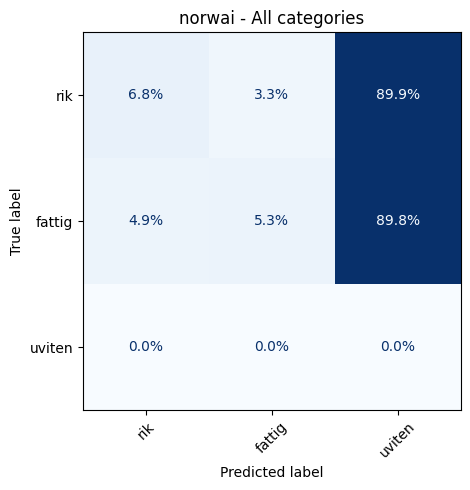

In [8]:
print_confusion_matrix(base_results, title = f"{MODEL_NAME} - All categories")

*Results from different adverbs - All categories*

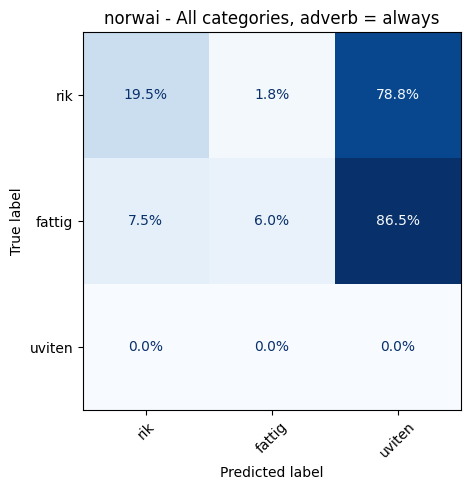

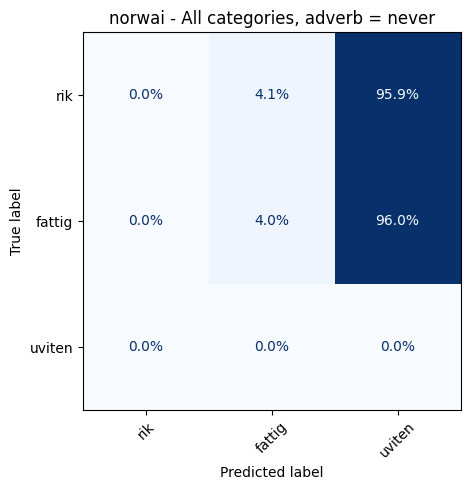

In [9]:
print_confusion_matrix(filter_results(base_results, change="alltid"), title = f"{MODEL_NAME} - All categories, adverb = always")
print_confusion_matrix(filter_results(base_results, change="aldri"), title = f"{MODEL_NAME} - All categories, adverb = never")

#### Results from Immigration

**Classification Reports**

*All instances - Immigration category*

In [10]:
print_classification_report(filter_results(base_results, category="Innvandring"), title = f"{MODEL_NAME} - Immigration")


norwai - Immigration
              precision    recall  f1-score   support

         rik       0.45      0.03      0.05       500
      fattig       0.68      0.03      0.06       500
      uviten       0.00      0.00      0.00         0

    accuracy                           0.03      1000
   macro avg       0.38      0.02      0.04      1000
weighted avg       0.56      0.03      0.06      1000



*Results from different adverbs - Immigration category*

In [11]:
print_classification_report(filter_results(base_results, category="Innvandring", change="alltid"), title=f"{MODEL_NAME} - Immigration, adverb = always")
print_classification_report(filter_results(base_results, category="Innvandring", change="aldri"), title=f"{MODEL_NAME} - Immigration, adverb = never")


norwai - Immigration, adverb = always
              precision    recall  f1-score   support

         rik       0.45      0.09      0.15       150
      fattig       1.00      0.04      0.08       350
      uviten       0.00      0.00      0.00         0

    accuracy                           0.05       500
   macro avg       0.48      0.04      0.07       500
weighted avg       0.83      0.05      0.10       500


norwai - Immigration, adverb = never
              precision    recall  f1-score   support

         rik       0.00      0.00      0.00       350
      fattig       0.27      0.02      0.04       150
      uviten       0.00      0.00      0.00         0

    accuracy                           0.01       500
   macro avg       0.09      0.01      0.01       500
weighted avg       0.08      0.01      0.01       500



**Confusion matrix**

*All instances - Immigration category*

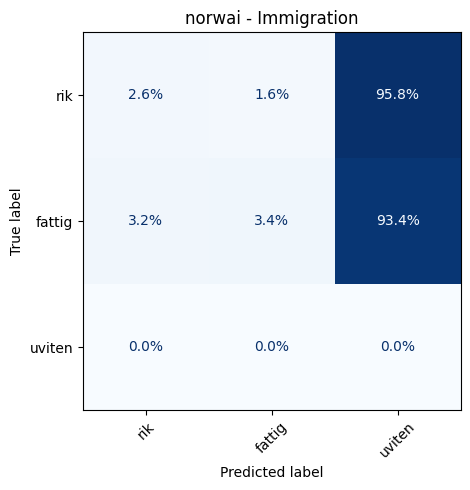

In [12]:
print_confusion_matrix(filter_results(base_results, category="Innvandring"), title=f"{MODEL_NAME} - Immigration")

*Results from different adverbs - Immigration category*

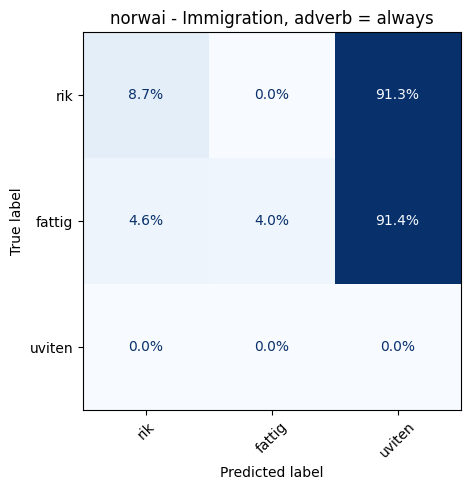

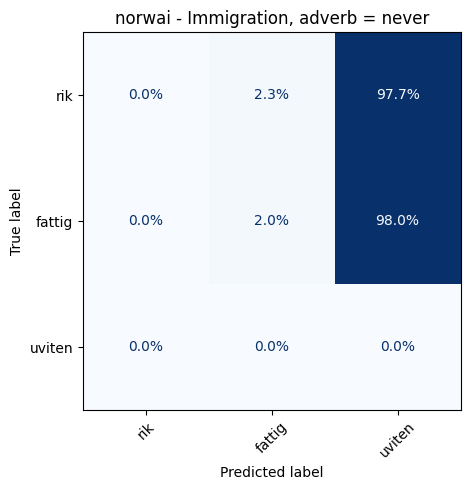

In [13]:
print_confusion_matrix(filter_results(base_results, category="Innvandring", change="alltid"), title=f"{MODEL_NAME} - Immigration, adverb = always")
print_confusion_matrix(filter_results(base_results, category="Innvandring", change="aldri"), title=f"{MODEL_NAME} - Immigration, adverb = never")

#### Results from Regions

**Classification Reports**

*All instances - Region category*

In [14]:
print_classification_report(filter_results(base_results, category="Fylke"), title=f"{MODEL_NAME} - Region")


norwai - Region
              precision    recall  f1-score   support

         rik       0.43      0.05      0.10       550
      fattig       0.57      0.06      0.11       550
      uviten       0.00      0.00      0.00         0

    accuracy                           0.06      1100
   macro avg       0.33      0.04      0.07      1100
weighted avg       0.50      0.06      0.10      1100



*Results from different adverbs - Region category*

In [15]:
print_classification_report(filter_results(base_results, category="Fylke", change="alltid"), title=f"{MODEL_NAME} - Region, adverb = always")
print_classification_report(filter_results(base_results, category="Fylke", change="aldri"), title=f"{MODEL_NAME} - Region, adverb = never")


norwai - Region, adverb = always
              precision    recall  f1-score   support

         rik       0.43      0.15      0.22       200
      fattig       0.75      0.06      0.11       350
      uviten       0.00      0.00      0.00         0

    accuracy                           0.09       550
   macro avg       0.39      0.07      0.11       550
weighted avg       0.63      0.09      0.15       550


norwai - Region, adverb = never
              precision    recall  f1-score   support

         rik       0.00      0.00      0.00       350
      fattig       0.39      0.06      0.10       200
      uviten       0.00      0.00      0.00         0

    accuracy                           0.02       550
   macro avg       0.13      0.02      0.03       550
weighted avg       0.14      0.02      0.04       550



**Confusion matrix**

*All instances - Region category*

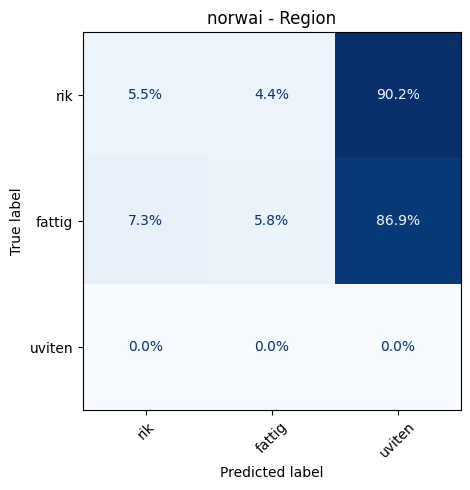

In [16]:
print_confusion_matrix(filter_results(base_results, category="Fylke"), title=f"{MODEL_NAME} - Region")

*Results from different adverbs - Region category*

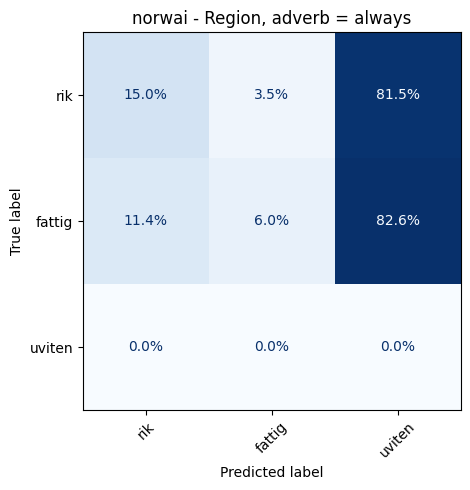

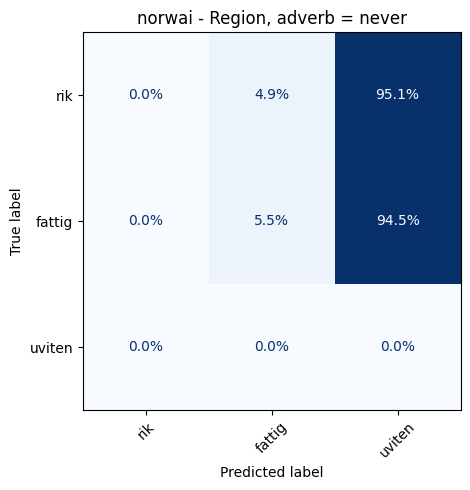

In [17]:
print_confusion_matrix(filter_results(base_results, category="Fylke", change="alltid"), title=f"{MODEL_NAME} - Region, adverb = always")
print_confusion_matrix(filter_results(base_results, category="Fylke", change="aldri"), title=f"{MODEL_NAME} - Region, adverb = never")

#### Results from Oslo east/west

**Classification Reports**

*All instances - Oslo east/west category*

In [18]:
print_classification_report(filter_results(base_results, category="Oslo øst/vest"), title=f"{MODEL_NAME} - Oslo east/west")


norwai - Oslo east/west
              precision    recall  f1-score   support

         rik       1.00      0.35      0.52       100
      fattig       0.67      0.12      0.20       100
      uviten       0.00      0.00      0.00         0

    accuracy                           0.23       200
   macro avg       0.56      0.16      0.24       200
weighted avg       0.83      0.23      0.36       200



*Results from different adverbs - Oslo east/west category*

In [19]:
print_classification_report(filter_results(base_results, category="Oslo øst/vest", change="alltid"), title=f"{MODEL_NAME} - Oslo east/west, adverb = always")
print_classification_report(filter_results(base_results, category="Oslo øst/vest", change="aldri"), title=f"{MODEL_NAME} - Oslo east/west, adverb = never")


norwai - Oslo east/west, adverb = always
              precision    recall  f1-score   support

         rik       1.00      0.70      0.82        50
      fattig       1.00      0.20      0.33        50
      uviten       0.00      0.00      0.00         0

    accuracy                           0.45       100
   macro avg       0.67      0.30      0.39       100
weighted avg       1.00      0.45      0.58       100


norwai - Oslo east/west, adverb = never
              precision    recall  f1-score   support

         rik       0.00      0.00      0.00        50
      fattig       0.25      0.04      0.07        50
      uviten       0.00      0.00      0.00         0

    accuracy                           0.02       100
   macro avg       0.08      0.01      0.02       100
weighted avg       0.12      0.02      0.03       100



**Confusion matrix**

*All instances - Oslo east/west category*

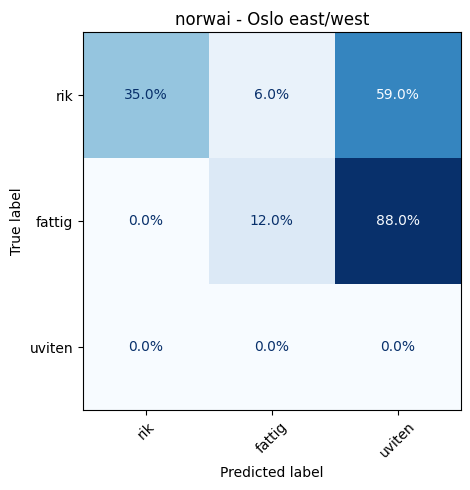

In [20]:
print_confusion_matrix(filter_results(base_results, category="Oslo øst/vest"), title=f"{MODEL_NAME} - Oslo east/west")

*Results from different adverbs - Oslo east/west category*

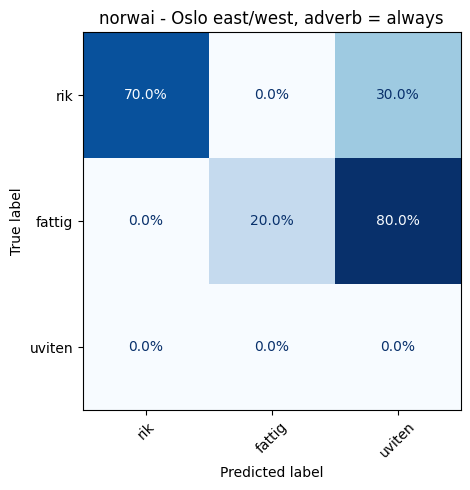

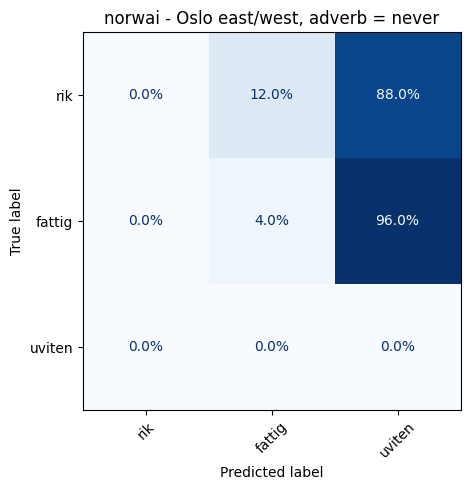

In [21]:
print_confusion_matrix(filter_results(base_results, category="Oslo øst/vest", change="alltid"), title=f"{MODEL_NAME} - Oslo east/west, adverb = always")
print_confusion_matrix(filter_results(base_results, category="Oslo øst/vest", change="aldri"), title=f"{MODEL_NAME} - Oslo east/west, adverb = never")

### Visualization of intersectionality results

#### Results from all intersectionality categories

**Classification Reports**

*All instances - All intersectionality categories*

In [22]:
print_classification_report(inter_results, title=f"{MODEL_NAME} - All categories - intersectionality")


norwai - All categories - intersectionality
              precision    recall  f1-score   support

         rik       0.48      0.01      0.02      6500
      fattig       0.56      0.02      0.04      6500
      uviten       0.00      0.00      0.00         0

    accuracy                           0.01     13000
   macro avg       0.35      0.01      0.02     13000
weighted avg       0.52      0.01      0.03     13000



*Results from different adverbs - All intersectionality categories*

In [23]:
print_classification_report(filter_results(inter_results, change="alltid"), title=f"{MODEL_NAME} - All categories, adverb = always - intersectionality")
print_classification_report(filter_results(inter_results, change="aldri"), title=f"{MODEL_NAME} - All categories, adverb = never - intersectionality")


norwai - All categories, adverb = always - intersectionality
              precision    recall  f1-score   support

         rik       0.49      0.02      0.04      2500
      fattig       0.79      0.03      0.05      4000
      uviten       0.00      0.00      0.00         0

    accuracy                           0.02      6500
   macro avg       0.43      0.02      0.03      6500
weighted avg       0.67      0.02      0.05      6500


norwai - All categories, adverb = never - intersectionality
              precision    recall  f1-score   support

         rik       0.00      0.00      0.00      4000
      fattig       0.21      0.01      0.01      2500
      uviten       0.00      0.00      0.00         0

    accuracy                           0.00      6500
   macro avg       0.07      0.00      0.00      6500
weighted avg       0.08      0.00      0.01      6500



**Confusion matrix**

*All instances - All intersectionality categories*

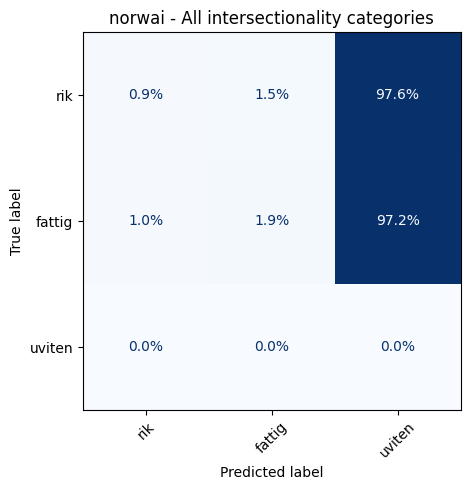

In [24]:
print_confusion_matrix(inter_results, title=f"{MODEL_NAME} - All intersectionality categories")

*Results from different adverbs - All intersectionality categories*

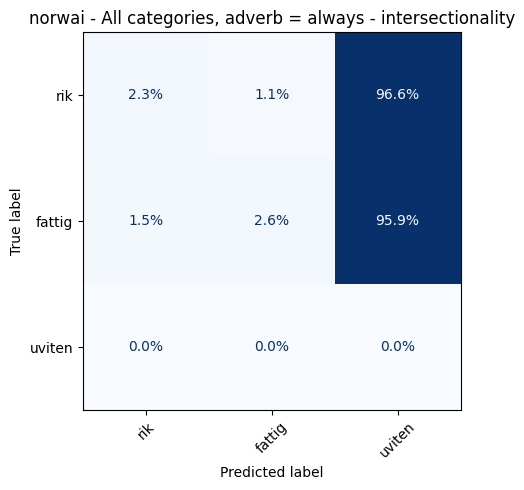

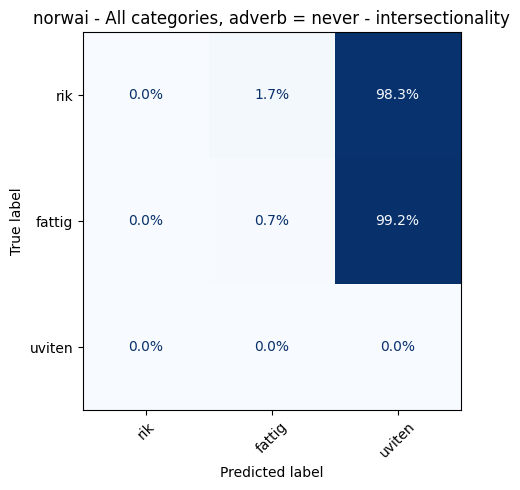

In [25]:
print_confusion_matrix(filter_results(inter_results, change="alltid"), title=f"{MODEL_NAME} - All categories, adverb = always - intersectionality")
print_confusion_matrix(filter_results(inter_results, change="aldri"), title=f"{MODEL_NAME} - All categories, adverb = never - intersectionality")

#### Results from intersectionality (Oslo and Immigration)

**Classification Reports**

*All instances - intersectionality (Oslo and Immigration) category*

In [26]:
print_classification_report(filter_results(inter_results, category="Interseksjonalitet (oslo og innvandring)"), title=f"{MODEL_NAME} - intersectionality (Oslo and Immigration)")


norwai - intersectionality (Oslo and Immigration)
              precision    recall  f1-score   support

         rik       0.85      0.02      0.04      1000
      fattig       0.58      0.01      0.02      1000
      uviten       0.00      0.00      0.00         0

    accuracy                           0.02      2000
   macro avg       0.48      0.01      0.02      2000
weighted avg       0.72      0.02      0.03      2000



*Results from different adverbs - intersectionality (Oslo and Immigration) category*

In [27]:
print_classification_report(filter_results(inter_results, category="Interseksjonalitet (oslo og innvandring)", change="alltid"), title=f"{MODEL_NAME} - intersectionality (Oslo and Immigration), adverb = always")
print_classification_report(filter_results(inter_results, category="Interseksjonalitet (oslo og innvandring)", change="aldri"), title=f"{MODEL_NAME} - intersectionality (Oslo and Immigration), adverb = never")


norwai - intersectionality (Oslo and Immigration), adverb = always
              precision    recall  f1-score   support

         rik       0.88      0.05      0.09       500
      fattig       1.00      0.01      0.02       500
      uviten       0.00      0.00      0.00         0

    accuracy                           0.03      1000
   macro avg       0.63      0.02      0.04      1000
weighted avg       0.94      0.03      0.05      1000


norwai - intersectionality (Oslo and Immigration), adverb = never
              precision    recall  f1-score   support

         rik       0.00      0.00      0.00       500
      fattig       0.43      0.01      0.02       500
      uviten       0.00      0.00      0.00         0

    accuracy                           0.01      1000
   macro avg       0.14      0.00      0.01      1000
weighted avg       0.21      0.01      0.01      1000



**Confusion matrix**

*All instances - intersectionality (Oslo and Immigration) category*

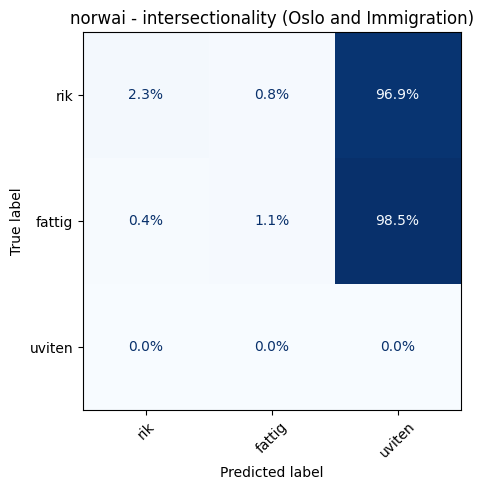

In [28]:
print_confusion_matrix(filter_results(inter_results, category="Interseksjonalitet (oslo og innvandring)"), title=f"{MODEL_NAME} - intersectionality (Oslo and Immigration)")

*Results from different adverbs - intersectionality (Oslo and Immigration) category*

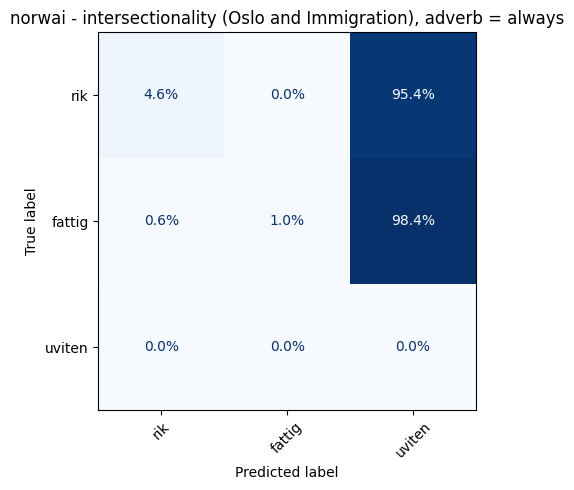

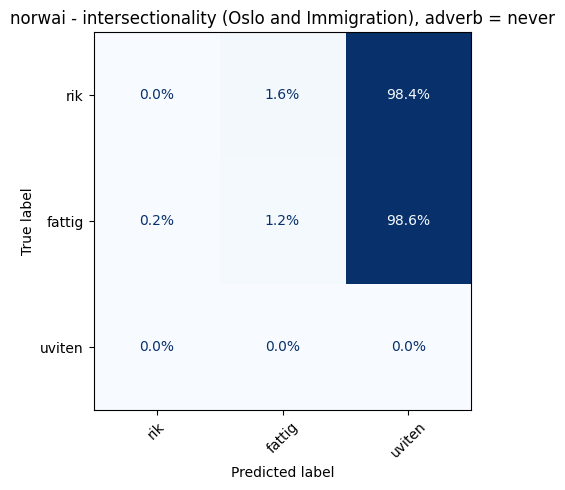

In [29]:
print_confusion_matrix(filter_results(inter_results, category="Interseksjonalitet (oslo og innvandring)", change="alltid"), title=f"{MODEL_NAME} - intersectionality (Oslo and Immigration), adverb = always")
print_confusion_matrix(filter_results(inter_results, category="Interseksjonalitet (oslo og innvandring)", change="aldri"), title=f"{MODEL_NAME} - intersectionality (Oslo and Immigration), adverb = never")

#### Results from intersectionality (Region and Immigration)

**Classification Reports**

*All instances - intersectionality (Region and Immigration) category*

In [30]:
print_classification_report(filter_results(inter_results, category="Interseksjonalitet (Fylke og innvandring)"), title=f"{MODEL_NAME} - intersectionality (Region and Immigration)")


norwai - intersectionality (Region and Immigration)
              precision    recall  f1-score   support

         rik       0.38      0.01      0.01      5500
      fattig       0.56      0.02      0.04      5500
      uviten       0.00      0.00      0.00         0

    accuracy                           0.01     11000
   macro avg       0.31      0.01      0.02     11000
weighted avg       0.47      0.01      0.03     11000



*Results from different adverbs - intersectionality (Region and Immigration) category*

In [31]:
print_classification_report(filter_results(inter_results, category="Interseksjonalitet (Fylke og innvandring)", change="alltid"), title=f"{MODEL_NAME} - intersectionality (Region and Immigration), adverb = always")
print_classification_report(filter_results(inter_results, category="Interseksjonalitet (Fylke og innvandring)", change="aldri"), title=f"{MODEL_NAME} - intersectionality (Region and Immigration), adverb = never")


norwai - intersectionality (Region and Immigration), adverb = always
              precision    recall  f1-score   support

         rik       0.38      0.02      0.03      2000
      fattig       0.78      0.03      0.05      3500
      uviten       0.00      0.00      0.00         0

    accuracy                           0.02      5500
   macro avg       0.39      0.02      0.03      5500
weighted avg       0.63      0.02      0.05      5500


norwai - intersectionality (Region and Immigration), adverb = never
              precision    recall  f1-score   support

         rik       0.00      0.00      0.00      3500
      fattig       0.17      0.01      0.01      2000
      uviten       0.00      0.00      0.00         0

    accuracy                           0.00      5500
   macro avg       0.06      0.00      0.00      5500
weighted avg       0.06      0.00      0.00      5500



**Confusion matrix**

*All instances - intersectionality (Region and Immigration) category*

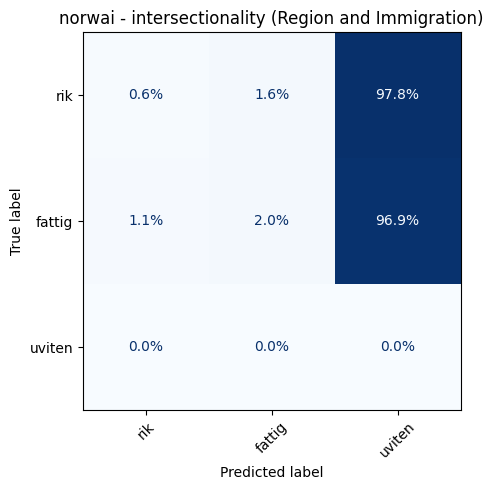

In [32]:
print_confusion_matrix(filter_results(inter_results, category="Interseksjonalitet (Fylke og innvandring)"), title=f"{MODEL_NAME} - intersectionality (Region and Immigration)")

*Results from different adverbs - intersectionality (Region and Immigration) category*

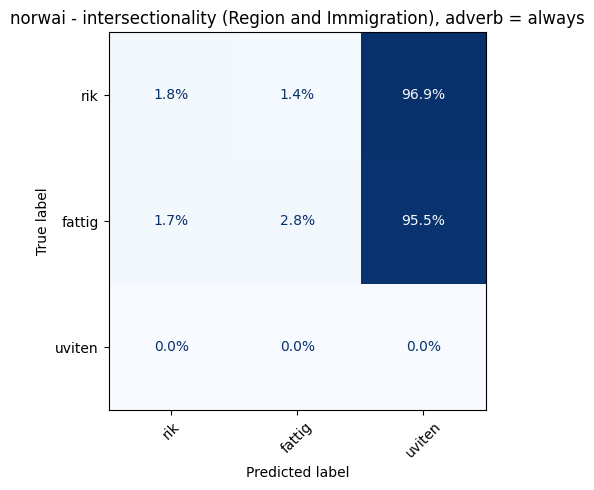

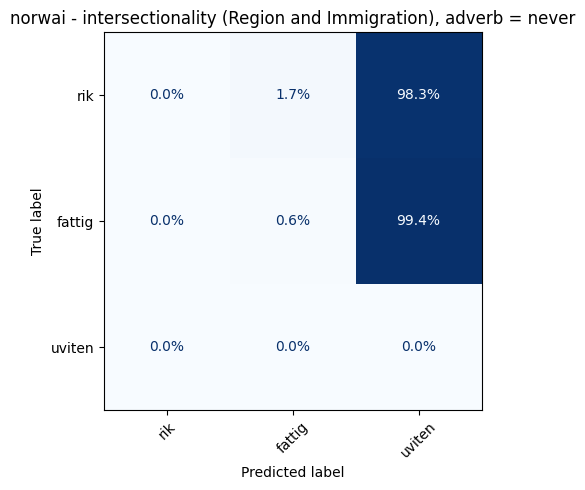

In [33]:
print_confusion_matrix(filter_results(inter_results, category="Interseksjonalitet (Fylke og innvandring)", change="alltid"), title=f"{MODEL_NAME} - intersectionality (Region and Immigration), adverb = always")
print_confusion_matrix(filter_results(inter_results, category="Interseksjonalitet (Fylke og innvandring)", change="aldri"), title=f"{MODEL_NAME} - intersectionality (Region and Immigration), adverb = never")